# ANALISI SU DATAFRAME A LIVELLO COMUNALE CON DF AGGREGATO DAL 2001 AL 2024

L'analisi temporale ha evidenziato un trend decrescente degli incidenti nel periodo 2001-2024. Tuttavia, questa analisi non considera le differenze strutturali tra i comuni. Per questo motivo, nel notebook successivo viene effettuata un'analisi a livello comunale, aggregando gli incidenti sull'intero periodo (2001-2024) e studiando come caratteristiche demografiche e territoriali influenzino l'incidentalità.

# LIBRERIE

In [29]:
import pandas as pd
import os
import FUNCTIONS as fn

#grafici
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

# ANALISI ESPLORATIVA INTRO 

Carico i tre df, quello totale, quello solo degli incidenti, quello dei feriti e quello dei morti. Tutti questi presentano registrazioni dall' anno 2001 al 2024

In [30]:
os.getcwd()

'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Notebooks'

In [31]:
os.listdir()

['00_fetching.ipynb',
 '01cleaning_overview.ipynb',
 '02a.EDA_&_Temporal_analysis.ipynb',
 '02b_EDA_Municipality_analysis_aggregate_01_24.ipynb',
 '03b_Test.ipynb',
 'FUNCTIONS.py',
 '__pycache__']

In [32]:
os.listdir("../Data/Df_clean")

['df_feriti_from_01_to_24.csv',
 'df_final_from_01_to_24_clean.csv',
 'df_incidenti_from_01_to_24.csv',
 'df_morti_from_01_to_24.csv']

In [33]:
df_total= pd.read_csv ("../Data/Df_clean/df_final_from_01_to_24_clean.csv")
df_total

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,10,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,10,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,7,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,13,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,2,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573547,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,2,2549.0,27.1937
573548,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,5,2536.0,27.1943
573549,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,1,2575.0,27.1943
573550,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,4,2616.0,27.1943


In [34]:
df_accidents= pd.read_csv ("../Data/Df_clean/df_incidenti_from_01_to_24.csv")
df_accidents

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,5,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,5,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,4,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,9,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,2,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191179,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,2,2549.0,27.1937
191180,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,5,2536.0,27.1943
191181,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,1,2575.0,27.1943
191182,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,4,2616.0,27.1943


In [35]:
df_wounded= pd.read_csv ("../Data/Df_clean/df_feriti_from_01_to_24.csv")
df_wounded

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,10,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,10,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,7,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,13,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,feriti,2,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191179,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,feriti,3,2549.0,27.1937
191180,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,feriti,7,2536.0,27.1943
191181,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,feriti,1,2575.0,27.1943
191182,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,feriti,5,2616.0,27.1943


In [36]:
df_deaths= pd.read_csv ("../Data/Df_clean/df_morti_from_01_to_24.csv")
df_deaths

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191179,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2549.0,27.1937
191180,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2536.0,27.1943
191181,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2575.0,27.1943
191182,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2616.0,27.1943


# EDA

## RAGGRUPPO INCIDENTI/FERITI/MORTI PER COMUNE aggregando gli anni dal 01 al 24 e creazioni colonne con numero di osservazioni medie per anno, densità della superficie media, densità delle osservazioni media e incidenti pro capite medi (feature engineering)

Ora posso creare i df, dopo aver valutato che chiavi utilizzare e in che modo

In [ ]:
import importlib
importlib.reload(fn) #mi ricarica FUNCTIONS perchè c'era un errore

<module 'FUNCTIONS' from 'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Notebooks\\FUNCTIONS.py'>

In [39]:
df_accidents_municipality = fn.create_municipality_dataset(df_accidents,value_name="INCIDENTI")

In [40]:
df_wounded_municipality = fn.create_municipality_dataset(df_wounded,value_name="FERITI")

In [41]:
df_deaths_municipality = fn.create_municipality_dataset(df_deaths,value_name="MORTI")

AGGIUNTA COLONNE CLASSIFICAZIONE IN BASE A CLASSE DEMOGRAFICA E DI SUPERFICIE (al df_accidents_municipality)

Creo le colonne per la classificazione dei comuni in base alla superficie e alla demografia secondo la classificazione ufficiale:

-Classificazione Comuni per superficie -> https://www.istat.it/it/files/2015/04/Superfici-delle-unit%C3%A0-amministrative-Testo-integrale.pdf

-Classificazione comuni per classe demografica (da comprimere) ->https://finanzalocale.interno.gov.it/docum/studi/varie/200707varclass.html#due

In [42]:
#ANDANDO AD ANALIZZARE I COMUNI, VOGLIO CAPIRE ANCHE QUALI SIANO LE DIFFERENZE
# TRA CLASSI DEMOGRAFICHE E QUELLE DI SUPERFICIE, DUNQUE LI CLASSIFICO IN COLONNE
df_accidents_municipality["CLASSE_DEMOGRAFICA"] = ""

for i in df_accidents_municipality.index:

    residenti = df_accidents_municipality.loc[i, "RESIDENTI"]

    if residenti < 1000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Molto piccolo"
    elif residenti < 5000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Piccolo"
    elif residenti < 20000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Medio"

    else:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Grande"


df_accidents_municipality["CLASSE_SUPERFICIE"] = ""

for i in df_accidents_municipality.index:

    superficie = df_accidents_municipality.loc[i, "SUPERFICIE (KMQ)"]

    if superficie < 10:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto piccolo"
    elif superficie < 50:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Piccolo"
    elif superficie < 100:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Medio"
    elif superficie < 250:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Grande"

    else:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto grande"

In [43]:
print(df_accidents_municipality["CLASSE_DEMOGRAFICA"].value_counts())
print("-"*50)
print(df_accidents_municipality["CLASSE_SUPERFICIE"].value_counts())
print("-"*50)
#Totale dei miei comuni
tot_df = len(df_accidents_municipality)
print("Totale dei comuni registrati: ",tot_df)

CLASSE_DEMOGRAFICA
Piccolo          3788
Molto piccolo    2030
Medio            1909
Grande            506
Name: count, dtype: int64
--------------------------------------------------
CLASSE_SUPERFICIE
Piccolo          4767
Molto piccolo    1740
Medio            1124
Grande            532
Molto grande       70
Name: count, dtype: int64
--------------------------------------------------
Totale dei comuni registrati:  8233


In [44]:
#Creo le classi con i comuni per classe demografica con pochi residenti e con molti, dopodichè guardo quanto rappresentano ciascuna
#in % sul totale e farò lo stesso con i comuni per classe superficie, voglio vedere quanti sono e quanto pesino sul totale.
#Inoltre voglio osservare in % quanto pesa ogni variabile della classe sul totale dei record registrati nel df.
class_few_resident = df_accidents_municipality[df_accidents_municipality["CLASSE_DEMOGRAFICA"].isin(["Piccolo", "Molto piccolo"])]
class_many_resident = df_accidents_municipality[df_accidents_municipality["CLASSE_DEMOGRAFICA"].isin(["Medio", "Grande"])]
perc_few = len(class_few_resident) / tot_df * 100
perc_many = len(class_many_resident) / tot_df * 100


print ("="*40)
print ("IN BASE ALLA CLASSE DEMOGRAFICA")
print ("="*40)
print(f"Piccolo + Molto Piccolo: {len(class_few_resident)} comuni ({perc_few:.2f}%)")
print(f"Medio + Grande: {len(class_many_resident)} comuni ({perc_many:.2f}%)")
print ("."*40)
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Grande")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Medio")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Piccolo")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Molto piccolo")


IN BASE ALLA CLASSE DEMOGRAFICA
Piccolo + Molto Piccolo: 5818 comuni (70.67%)
Medio + Grande: 2415 comuni (29.33%)
........................................
Comuni 'Grande': 506 (6.15%)
Comuni 'Medio': 1909 (23.19%)
Comuni 'Piccolo': 3788 (46.01%)
Comuni 'Molto piccolo': 2030 (24.66%)


La distribuzione dei comuni in base alla classe demografica propende verso i comuni piccoli e molto piccoli, nella cella successiva osserverò se accadrà la stessa cosa con la classe di superficie.

In [45]:
class_few_sup = df_accidents_municipality[df_accidents_municipality["CLASSE_SUPERFICIE"].isin(["Piccolo", "Molto piccolo"])]
class_many_sup = df_accidents_municipality[df_accidents_municipality["CLASSE_SUPERFICIE"].isin(["Medio", "Grande", "Molto grande"])]
perc_few = len(class_few_sup) / tot_df * 100
perc_many = len(class_many_sup) / tot_df * 100

print ("="*40)
print ("IN BASE ALLA CLASSE DI SUPERFICIE")
print ("="*40)
print(f"Piccolo + Molto Piccolo: {len(class_few_sup)} comuni ({perc_few:.2f}%)")
print(f"Medio + Grande+ Molto grande: {len(class_many_sup)} comuni ({perc_many:.2f}%)")
print ("."*40)
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Molto grande")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Grande")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Medio")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Piccolo")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Molto piccolo")


IN BASE ALLA CLASSE DI SUPERFICIE
Piccolo + Molto Piccolo: 6507 comuni (79.04%)
Medio + Grande+ Molto grande: 1726 comuni (20.96%)
........................................
Comuni 'Molto grande': 70 (0.85%)
Comuni 'Grande': 532 (6.46%)
Comuni 'Medio': 1124 (13.65%)
Comuni 'Piccolo': 4767 (57.9%)
Comuni 'Molto piccolo': 1740 (21.13%)


La distribuzione viene confermata anche per la classe di superficie, in cui la maggioranza dei comuni si trova nelle classi "Piccolo" e "Molto piccolo"

## DATA OVERVIEW e CLEANING CHECK

Prima di iniziare con l' analisi esplorativa ricontrollo la pulizia dei dati del mio df

In [46]:
df_accidents_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8233 non-null   float64
 1   COMUNE                            8233 non-null   str    
 2   INCIDENTI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                         8233 non-null   float64
 4   SUPERFICIE (KMQ)                  8233 non-null   float64
 5   ID_REGIONE                        8233 non-null   float64
 6   REGIONE                           8233 non-null   str    
 7   N_ANNI                            8233 non-null   int64  
 8   INCIDENTI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE               8233 non-null   float64
 10  DENSITA_INCIDENTI_MEDIA           8233 non-null   float64
 11  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
 12  CLASSE_DEMOGRAFIC

In [47]:
df_wounded_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_COMUNE                      8233 non-null   float64
 1   COMUNE                         8233 non-null   str    
 2   FERITI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                      8233 non-null   float64
 4   SUPERFICIE (KMQ)               8233 non-null   float64
 5   ID_REGIONE                     8233 non-null   float64
 6   REGIONE                        8233 non-null   str    
 7   N_ANNI                         8233 non-null   int64  
 8   FERITI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE            8233 non-null   float64
 10  DENSITA_FERITI_MEDIA           8233 non-null   float64
 11  FERITI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
dtypes: float64(8), int64(2), str(2)
memory usage: 772.0 KB


In [48]:
df_deaths_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_COMUNE                     8233 non-null   float64
 1   COMUNE                        8233 non-null   str    
 2   MORTI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                     8233 non-null   float64
 4   SUPERFICIE (KMQ)              8233 non-null   float64
 5   ID_REGIONE                    8233 non-null   float64
 6   REGIONE                       8233 non-null   str    
 7   N_ANNI                        8233 non-null   int64  
 8   MORTI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE           8233 non-null   float64
 10  DENSITA_MORTI_MEDIA           8233 non-null   float64
 11  MORTI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
dtypes: float64(8), int64(2), str(2)
memory usage: 772.0 KB


In [49]:
def change_type_col_Int64 (df, col):
    df[col] = (df[col].astype("int64"))

In [50]:
change_type_col_Int64(df_accidents_municipality,"ID_REGIONE")
change_type_col_Int64(df_wounded_municipality,"ID_REGIONE")
change_type_col_Int64(df_deaths_municipality,"ID_REGIONE")

In [51]:
fn.check_df (df_accidents_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8233 non-null   float64
 1   COMUNE                            8233 non-null   str    
 2   INCIDENTI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                         8233 non-null   float64
 4   SUPERFICIE (KMQ)                  8233 non-null   float64
 5   ID_REGIONE                        8233 non-null   int64  
 6   REGIONE                           8233 non-null   str    
 7   N_ANNI                            8233 non-null   int64  
 8   INCIDENTI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE               8233 non-null   float64
 10  DENSITA_INCIDENTI_MEDIA           8233 non-null   float64
 11  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
 12  CLASSE_DEMOGRAFIC

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
0,1001.0,Agliè,95,2630.541667,13.146217,1,Piemonte,24,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo
1,1002.0,Airasca,262,3699.041667,15.739300,1,Piemonte,24,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo
2,1003.0,Ala di Stura,6,463.875000,46.331517,1,Piemonte,24,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo
3,1004.0,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,24,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo
4,1005.0,Alice Superiore,21,687.222222,7.379600,1,Piemonte,18,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo


In [52]:
fn.check_df (df_wounded_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_COMUNE                      8233 non-null   float64
 1   COMUNE                         8233 non-null   str    
 2   FERITI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                      8233 non-null   float64
 4   SUPERFICIE (KMQ)               8233 non-null   float64
 5   ID_REGIONE                     8233 non-null   int64  
 6   REGIONE                        8233 non-null   str    
 7   N_ANNI                         8233 non-null   int64  
 8   FERITI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE            8233 non-null   float64
 10  DENSITA_FERITI_MEDIA           8233 non-null   float64
 11  FERITI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
dtypes: float64(7), int64(3), str(2)
memory usage: 772.0 KB
None

,ID_COMUNE,COMUNE,FERITI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,FERITI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
0,1001.0,Agliè,161,2630.541667,13.146217,1,Piemonte,24,6.708333,200.098761,0.510286,2.550172
1,1002.0,Airasca,427,3699.041667,15.739300,1,Piemonte,24,17.791667,235.019452,1.130398,4.809804
2,1003.0,Ala di Stura,10,463.875000,46.331517,1,Piemonte,24,0.416667,10.012083,0.008993,0.898230
3,1004.0,Albiano d'Ivrea,165,1696.000000,11.732788,1,Piemonte,24,6.875000,144.552179,0.585965,4.053656
4,1005.0,Alice Superiore,34,687.222222,7.379600,1,Piemonte,18,1.416667,93.124590,0.191971,2.061439


In [53]:
fn.check_df (df_deaths_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_COMUNE                     8233 non-null   float64
 1   COMUNE                        8233 non-null   str    
 2   MORTI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                     8233 non-null   float64
 4   SUPERFICIE (KMQ)              8233 non-null   float64
 5   ID_REGIONE                    8233 non-null   int64  
 6   REGIONE                       8233 non-null   str    
 7   N_ANNI                        8233 non-null   int64  
 8   MORTI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE           8233 non-null   float64
 10  DENSITA_MORTI_MEDIA           8233 non-null   float64
 11  MORTI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
dtypes: float64(7), int64(3), str(2)
memory usage: 772.0 KB
None
-------------

,ID_COMUNE,COMUNE,MORTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,MORTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
0,1001.0,Agliè,1,2630.541667,13.146217,1,Piemonte,24,0.041667,200.098761,0.003169,0.015840
1,1002.0,Airasca,8,3699.041667,15.739300,1,Piemonte,24,0.333333,235.019452,0.021178,0.090113
2,1003.0,Ala di Stura,0,463.875000,46.331517,1,Piemonte,24,0.000000,10.012083,0.000000,0.000000
3,1004.0,Albiano d'Ivrea,10,1696.000000,11.732788,1,Piemonte,24,0.416667,144.552179,0.035513,0.245676
4,1005.0,Alice Superiore,5,687.222222,7.379600,1,Piemonte,18,0.208333,93.124590,0.028231,0.303153


# STATISTICA DESCRITTIVA

Voglio capire la distribuzione dei dati e vedere se ci sono punti di analisi interessanti

In [54]:
print("---- Incidenti ----")
display(df_accidents_municipality[["INCIDENTI_TOTALI","INCIDENTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]].describe())

print("---- Feriti ----")
display(df_wounded_municipality[["FERITI_TOTALI","FERITI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_FERITI_MEDIA","FERITI_PRO_CAPITE(1000)_MEDIA"]].describe())

print("---- Morti ----")
display(df_deaths_municipality[["MORTI_TOTALI","MORTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_MORTI_MEDIA","MORTI_PRO_CAPITE(1000)_MEDIA"]].describe())

---- Incidenti ----


,INCIDENTI_TOTALI,INCIDENTI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA
count,8233.000000,8233.000000,8.233000e+03,8233.000000,8233.000000,8233.000000,8233.000000
mean,579.734483,24.155603,7.275629e+03,37.610191,291.480817,0.688255,1.916848
std,5867.403657,244.475152,4.032221e+04,50.072754,627.183615,1.909872,1.627636
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,24.000000,1.000000,1.014875e+03,11.296479,45.151223,0.042011,0.810252
50%,84.000000,3.500000,2.408958e+03,22.146100,104.849832,0.158075,1.535531
75%,272.000000,11.333333,6.020917e+03,43.800563,266.679978,0.552546,2.564879
max,390605.000000,16275.208333,2.693100e+06,1287.499925,12215.874974,62.497866,23.194112


---- Feriti ----


,FERITI_TOTALI,FERITI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
count,8233.000000,8233.000000,8.233000e+03,8233.000000,8233.000000,8233.000000,8233.000000
mean,813.781489,33.907562,7.275629e+03,37.610191,291.480817,0.975217,2.853410
std,7681.206933,320.050289,4.032221e+04,50.072754,627.183615,2.558764,2.482946
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,35.000000,1.458333,1.014875e+03,11.296479,45.151223,0.063446,1.192816
50%,127.000000,5.291667,2.408958e+03,22.146100,104.849832,0.241631,2.280096
75%,409.000000,17.041667,6.020917e+03,43.800563,266.679978,0.832465,3.817089
max,506345.000000,21097.708333,2.693100e+06,1287.499925,12215.874974,81.631438,37.230401


---- Morti ----


,MORTI_TOTALI,MORTI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
count,8233.000000,8233.000000,8.233000e+03,8233.000000,8233.000000,8233.000000,8233.000000
mean,12.366574,0.515274,7.275629e+03,37.610191,291.480817,0.016990,0.089151
std,59.557681,2.481570,4.032221e+04,50.072754,627.183615,0.026162,0.117676
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,1.000000,0.041667,1.014875e+03,11.296479,45.151223,0.001895,0.028075
50%,4.000000,0.166667,2.408958e+03,22.146100,104.849832,0.007747,0.064370
75%,11.000000,0.458333,6.020917e+03,43.800563,266.679978,0.021673,0.113773
max,4350.000000,181.250000,2.693100e+06,1287.499925,12215.874974,0.329063,3.061768


# CLASSIFICHE

-COMUNE CON PIù INCIDENTI/ FERITI/ MORTI: Roma sia per incidenti che per morti e feriti

-REGIONE CON PIù INCIDENTI/ FERITI/ MORTI: Lombardia sia per incidenti che per morti e feriti

In [55]:
#COMUNE CON PIù INCIDENTI
#display(df_accidents_municipality.loc[df_accidents_municipality["INCIDENTI_TOTALI"].idxmax()]) # modo 1 -per trovare il valore più alto di incidenti
display(df_accidents_municipality.sort_values("INCIDENTI_TOTALI", ascending=False).head())
#COMUNE CON PIù FERITI
display(df_wounded_municipality.sort_values("FERITI_TOTALI", ascending=False).head()) # modo 2 -per trovare il valore più alto di feriti
#COMUNE CON PIù MORTI
display(df_deaths_municipality.sort_values("MORTI_TOTALI", ascending=False).head())

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5014,58091.0,Roma,390605,2.693100e+06,1287.499925,12,Lazio,24,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1830,15146.0,Milano,272545,1.310566e+06,181.702871,3,Lombardia,24,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1291,10025.0,Genova,102694,5.862910e+05,240.190217,7,Liguria,24,4278.916667,2440.944375,17.814700,7.298282,Grande,Grande
271,1272.0,Torino,87227,8.728376e+05,130.021463,1,Piemonte,24,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
4498,48017.0,Firenze,74537,3.646007e+05,102.315325,9,Toscana,24,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande


,ID_COMUNE,COMUNE,FERITI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,FERITI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
5014,58091.0,Roma,506345,2.693100e+06,1287.499925,12,Lazio,24,21097.708333,2091.728018,16.386571,7.833987
1830,15146.0,Milano,355984,1.310566e+06,181.702871,3,Lombardia,24,14832.666667,7212.689425,81.631438,11.317753
271,1272.0,Torino,129752,8.728376e+05,130.021463,1,Piemonte,24,5406.333333,6713.027282,41.580315,6.193974
1291,10025.0,Genova,128139,5.862910e+05,240.190217,7,Liguria,24,5339.125000,2440.944375,22.228736,9.106613
4498,48017.0,Firenze,90339,3.646007e+05,102.315325,9,Toscana,24,3764.125000,3563.500466,36.789455,10.323965


,ID_COMUNE,COMUNE,MORTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,MORTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
5014,58091.0,Roma,4350,2.693100e+06,1287.499925,12,Lazio,24,181.250000,2091.728018,0.140777,0.067302
1830,15146.0,Milano,1435,1.310566e+06,181.702871,3,Lombardia,24,59.791667,7212.689425,0.329063,0.045623
271,1272.0,Torino,895,8.728376e+05,130.021463,1,Piemonte,24,37.291667,6713.027282,0.286812,0.042725
5399,63049.0,Napoli,881,9.588668e+05,118.998133,15,Campania,24,36.708333,8057.830529,0.308478,0.038283
6901,82053.0,Palermo,716,6.582088e+05,160.602017,19,Sicilia,24,29.833333,4098.384609,0.185759,0.045325


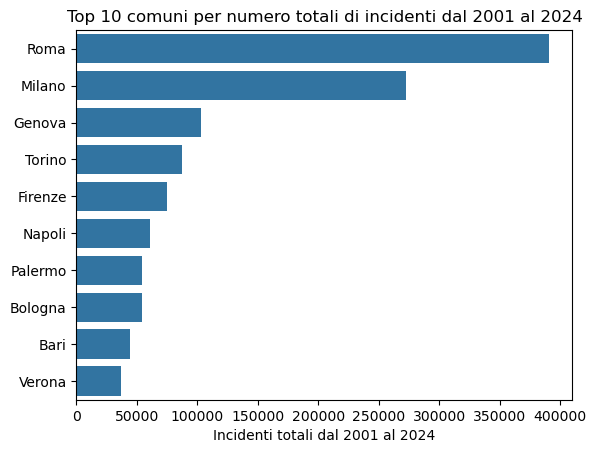

In [56]:
#BARPLOTS
top10 = (df_accidents_municipality.sort_values("INCIDENTI_TOTALI", ascending=False).head(10))

sns.barplot(data=top10,x="INCIDENTI_TOTALI",y="COMUNE")
plt.xlabel ("Incidenti totali dal 2001 al 2024")
plt.ylabel ("")
plt.title("Top 10 comuni per numero totali di incidenti dal 2001 al 2024")
plt.show()

In [57]:
display(df_accidents_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["INCIDENTI_TOTALI"].sum().sort_values("INCIDENTI_TOTALI", ascending=False).head()) #devo mettere as_index=false per far si che non esca una serie con indice l'id regionale
display(df_wounded_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["FERITI_TOTALI"].sum().sort_values("FERITI_TOTALI", ascending=False).head())
display(df_deaths_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["MORTI_TOTALI"].sum().sort_values("MORTI_TOTALI", ascending=False).head())


,ID_REGIONE,REGIONE,INCIDENTI_TOTALI
2,3,Lombardia,900236
11,12,Lazio,590275
7,8,Emilia-Romagna,477672
8,9,Toscana,424499
4,5,Veneto,373175


,ID_REGIONE,REGIONE,FERITI_TOTALI
2,3,Lombardia,1219236
11,12,Lazio,811262
7,8,Emilia-Romagna,649931
8,9,Toscana,559846
4,5,Veneto,513145


,ID_REGIONE,REGIONE,MORTI_TOTALI
2,3,Lombardia,14285
11,12,Lazio,10673
7,8,Emilia-Romagna,10587
4,5,Veneto,9836
0,1,Piemonte,7792


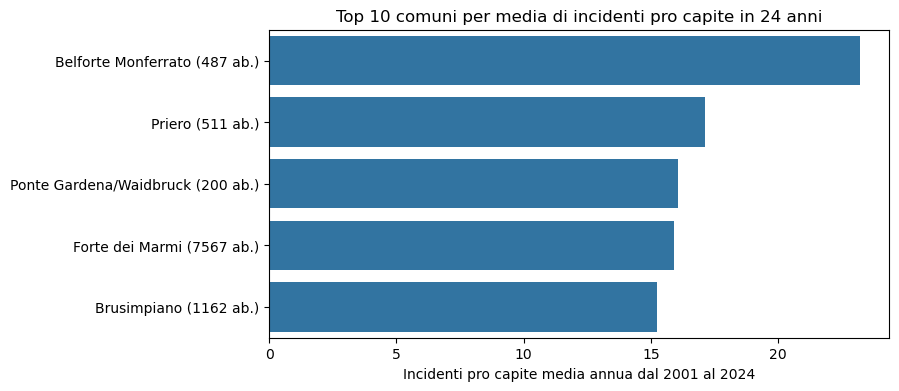

In [58]:
#BARPLOTS TOP 10 COMUNI INCIDENTI PRO CAPITE MEDI

top_pro_capite = (df_accidents_municipality.sort_values("INCIDENTI_PRO_CAPITE(1000)_MEDIA", ascending=False))
top_pro_capite["COMUNE"] = (top_pro_capite["COMUNE"] +" (" +
    top_pro_capite["RESIDENTI"].round().astype(int).astype(str) +
    " ab.)")

plt.figure(figsize=(8, 4))
sns.barplot(data=top_pro_capite.head(),x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",y="COMUNE")
plt.xlabel ("Incidenti pro capite media annua dal 2001 al 2024")
plt.ylabel ("")
plt.title("Top 10 comuni per media di incidenti pro capite in 24 anni")
plt.show()

In [59]:
#voglio osservare le classi demografiche e di superficie di chi è in top incidenti pro capite--> sono principalmente molto piccoli, 1 piccolo e 1 medio (Forte Dei Marmi)
top_pro_capite

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
877,6014.0,Belforte Monferrato (487 ab.),271,486.833333,8.325800,1,Piemonte,24,11.291667,58.472859,1.356226,23.194112,Molto piccolo,Molto piccolo
669,4175.0,Priero (511 ab.),210,511.000000,19.976367,1,Piemonte,24,8.750000,25.580227,0.438018,17.123288,Molto piccolo,Piccolo
2793,21065.0,Ponte Gardena/Waidbruck (200 ab.),77,199.625000,2.317742,4,Trentino-Alto Adige,24,3.208333,86.129098,1.384250,16.071801,Molto piccolo,Molto piccolo
4435,46013.0,Forte dei Marmi (7567 ab.),2887,7567.291667,8.957700,9,Toscana,24,120.291667,844.780654,13.428856,15.896264,Medio,Molto piccolo
1389,12024.0,Brusimpiano (1162 ab.),425,1162.375000,5.905800,3,Lombardia,24,17.708333,196.819229,2.998465,15.234613,Piccolo,Molto piccolo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,7016.0,Chamois (97 ab.),0,97.086957,14.528300,2,Valle d'Aosta,23,0.000000,6.682610,0.000000,0.000000,Molto piccolo,Piccolo
7460,94011.0,Castelpizzuto (153 ab.),0,153.478261,15.389400,14,Molise,23,0.000000,9.972985,0.000000,0.000000,Molto piccolo,Piccolo
532,4038.0,Canosio (84 ab.),0,84.043478,48.447600,1,Piemonte,23,0.000000,1.734729,0.000000,0.000000,Molto piccolo,Piccolo
6792,80066.0,Roccaforte del Greco (544 ab.),0,544.086957,43.856474,18,Calabria,23,0.000000,12.406081,0.000000,0.000000,Molto piccolo,Piccolo


# ANALISI UNIVARIATA (istogrammi, boxplot, barchart)

Da qui in poi farò l' analisi solamente sugli incidenti

Voglio osservare la distribuzione dei dati, essendo molto eterogenei utilizzerò una scala logaritmica però attenzione agli outlier, poichè le variabili vanno analizzate sui dati reali e non in scala

### Histograms & Boxplots 
Per vedere come sono distribuiti i dati

In [60]:
df_accidents_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8233 entries, 0 to 8232
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8233 non-null   float64
 1   COMUNE                            8233 non-null   str    
 2   INCIDENTI_TOTALI                  8233 non-null   int64  
 3   RESIDENTI                         8233 non-null   float64
 4   SUPERFICIE (KMQ)                  8233 non-null   float64
 5   ID_REGIONE                        8233 non-null   int64  
 6   REGIONE                           8233 non-null   str    
 7   N_ANNI                            8233 non-null   int64  
 8   INCIDENTI_MEDI_ANNUI              8233 non-null   float64
 9   DENSITA_POPOLAZIONE               8233 non-null   float64
 10  DENSITA_INCIDENTI_MEDIA           8233 non-null   float64
 11  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8233 non-null   float64
 12  CLASSE_DEMOGRAFIC

In [61]:
(df_accidents_municipality[["RESIDENTI","SUPERFICIE (KMQ)","INCIDENTI_MEDI_ANNUI", "DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]].describe()).round(2)

,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_MEDI_ANNUI,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA
count,8233.00,8233.00,8233.00,8233.00,8233.00
mean,7275.63,37.61,24.16,0.69,1.92
std,40322.21,50.07,244.48,1.91,1.63
min,35.87,0.12,0.00,0.00,0.00
25%,1014.88,11.30,1.00,0.04,0.81
50%,2408.96,22.15,3.50,0.16,1.54
75%,6020.92,43.80,11.33,0.55,2.56
max,2693099.67,1287.50,16275.21,62.50,23.19


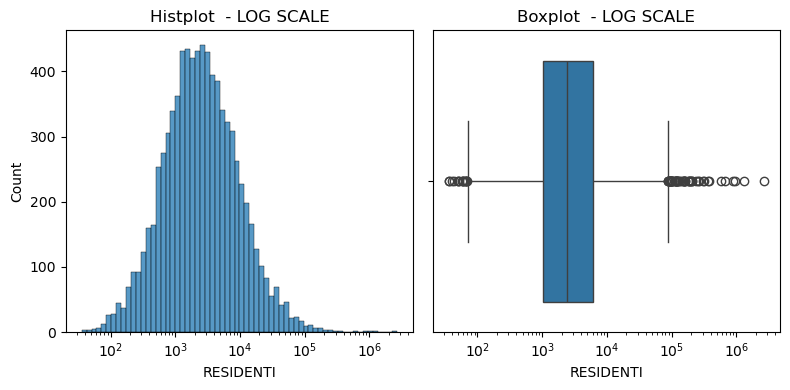

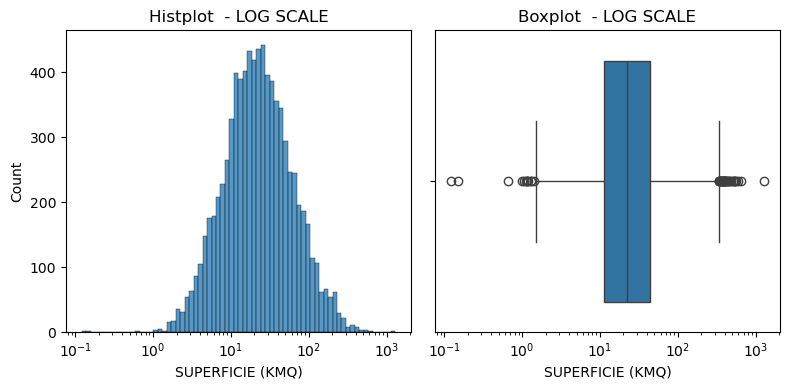

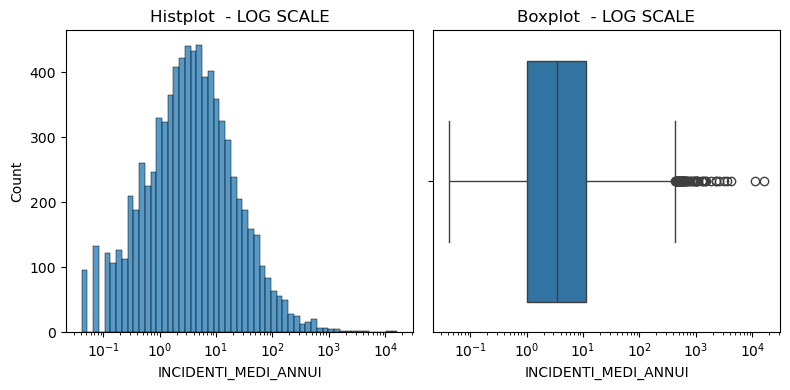

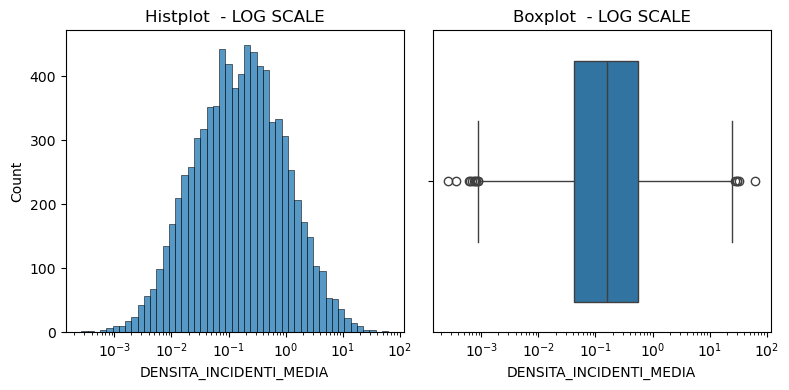

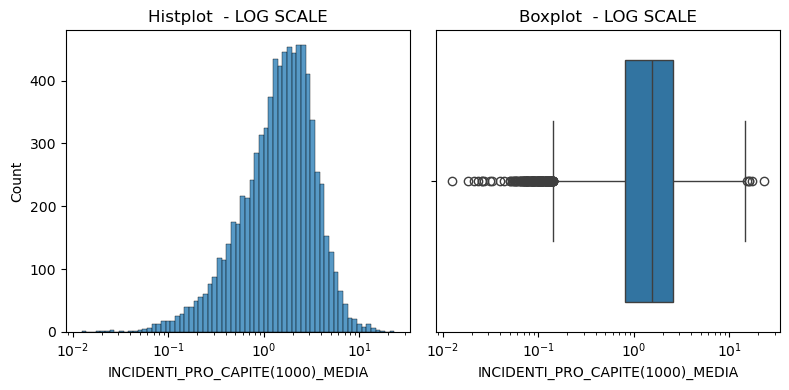

In [62]:
for col in ["RESIDENTI","SUPERFICIE (KMQ)","INCIDENTI_MEDI_ANNUI", "DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]:
    fn.plot_distr_logaritmic_scale(df_accidents_municipality, col)

Senza scala logaritmica noto che 

GRAFICI RESIDENTI: Distribuzione è asimmetrica a destra (right-skewed), vuol dire che ci sono tanti valori piccoli e pochi valori grandi o molto grandi, molti outlier oltre il Q3, comuni con molti residenti-->guardare outlier oltre Q3

GRAFICI SUPERFICIE: Distribuzione è asimmetrica a destra (right-skewed), vuol dire che ci sono tanti valori piccoli e pochi valori grandi o molto grandi, molti outlier oltre il Q3, comuni che ricoprono vasta area di superficie-->guardare outlier oltre Q3

GRAFICI INCIDENTI MEDI ANNUI-->dustribuzione asimmetrica a destra, ci sono pochi comuni con molti incidenti medi e sono outlier oltre il Q3--> osservare outlier oltr il Q3

GRAFICI DENSITA' INCIDENTI MEDIA-->dustribuzione asimmetrica a destra, ci sono pochi comuni che hanno molta densità di incidenti media e sono outlier oltre il Q3--> osservare outlier oltr il Q3

GRAFICI INCIDENTI PRO CAPITE MEDI-->dustribuzione asimmetrica a destra, ci sono pochi comuni con molti incidenti pro capite medi e sono outlier oltre il Q3--> osservare outlier oltr il Q3

Dall' analisi dei grafici ho notato che sostanzialmente la maggioranza dei valori delle variabili si aggira attorno ai valori piccoli


Asimmetria a destra: tanti valori piccoli e pochi valori molto grandi → è il caso tipico di popolazione, superficie e spesso anche degli incidenti.
Asimmetria a sinistra: tanti valori grandi e pochi molto piccoli.

- OBS_VALUE (Incidenti)

Si vede chiaramente che:

la distribuzione è fortemente asimmetrica a destra;
la maggior parte dei comuni registra poche decine o centinaia di incidenti;
pochi comuni raggiungono valori molto elevati.

Il boxplot conferma la presenza di numerosi outlier verso destra.


- DENSITA_INCIDENTI

L'istogramma sembra quasi una distribuzione normale se osservato sulla scala logaritmica. La trasformazione logaritmica ha reso la distribuzione molto più interpretabile.

Anche il boxplot è pulito.

- INCIDENTI_PRO_CAPITE

la distribuzione è ancora leggermente asimmetrica;
esistono outlier sia molto bassi sia molto alti.

Con la scala logaritmica riesci invece a vedere la forma della distribuzione.



Non ho cambiato i dati. Ho cambiato come li osservo.È la stessa differenza che c'è tra zoomare una foto e cambiare la foto.

# ANALISI BIVARIATA (Scatterplot...)

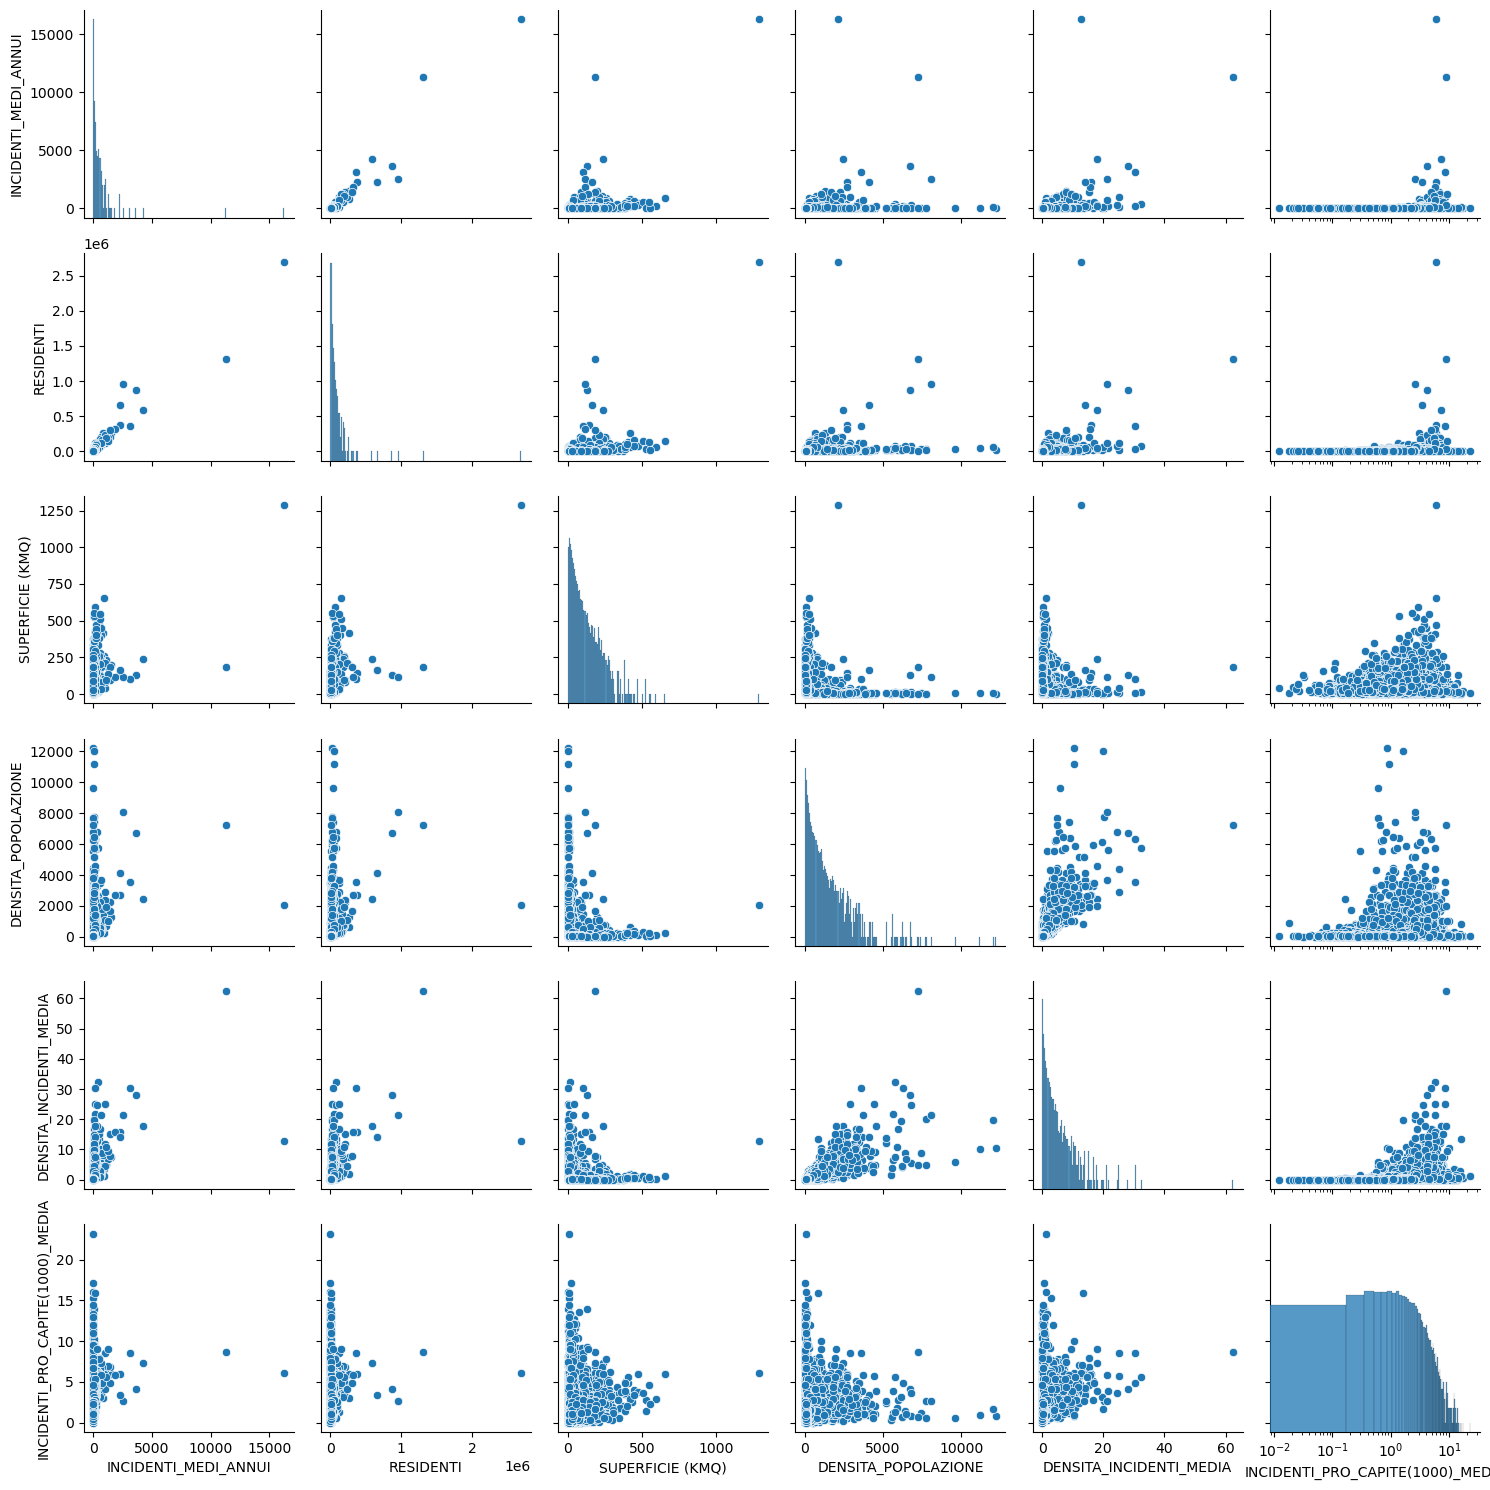

In [82]:
#PAIRPLOT
sns.pairplot(df_accidents_municipality[["INCIDENTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_INCIDENTI_MEDIA", "INCIDENTI_PRO_CAPITE(1000)_MEDIA"]])
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()


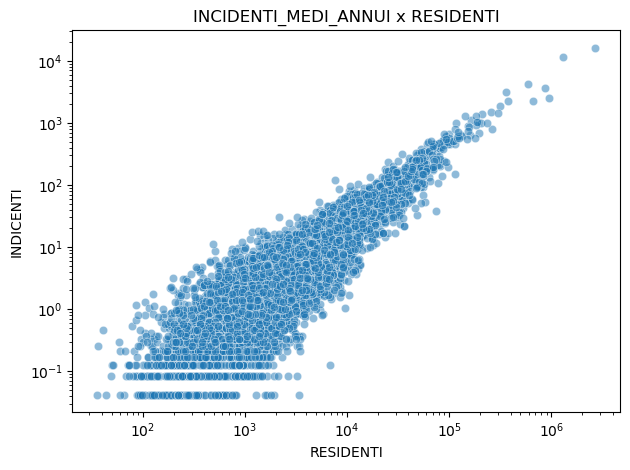

In [64]:
sns.scatterplot(data=df_accidents_municipality,x="RESIDENTI",y="INCIDENTI_MEDI_ANNUI", alpha=0.5)
plt.title("INCIDENTI_MEDI_ANNUI x RESIDENTI")
plt.ylabel("INDICENTI")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

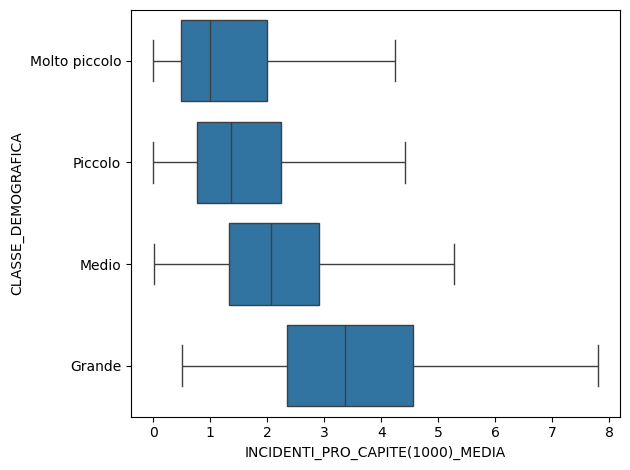

In [65]:
sns.boxplot(
    data=df_accidents_municipality,
    y="CLASSE_DEMOGRAFICA",
    x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio", "Grande"],
    showfliers=False #non mostrare gli outlier nel boxplot.
)
plt.tight_layout()
plt.show()

Le mediane aumentano all' aumentare della classe demografica (si passa da circa 1 per le classi molto piccole a 3.2 per quelle Grandi).

Gli intervalli interquartili (box) si spostano verso dx.

I whiskers divengono più ampi con l' aumento della classe.

I comuni grandi sono chiaramente spostati verso destra, dunque i valori per quei comuni saranno maggiori rispetto a quelli piccoli, nella classifica che è stata fatta prima per la top incidenti pro capite medi in termini assoluti primeggiavano i molto piccoli. La differenza tra queste classi sarà da valutare con dei test successivamente.

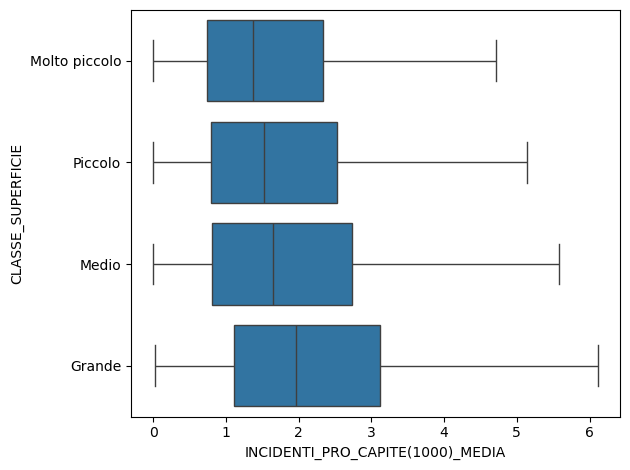

In [66]:
sns.boxplot(
    data=df_accidents_municipality,
    y="CLASSE_SUPERFICIE",
    x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio", "Grande"],
    showfliers=False #non mostrare gli outlier nel boxplot.
)
plt.tight_layout()
plt.show()

Le mediane sono molto simili (circa 1.3–1.7).

Gli intervalli interquartili (box) sono quasi sovrapposti.

Anche i whisker hanno lunghezze simili.

Non c'è una classe che sia chiaramente spostata verso destra come accadeva con i comuni grandi nella classe demografica.

# CORRELAZIONI TRA VARIABILI

In [67]:
corr_accidents=df_accidents_municipality [["INCIDENTI_MEDI_ANNUI","SUPERFICIE (KMQ)","RESIDENTI", "INCIDENTI_PRO_CAPITE(1000)_MEDIA","DENSITA_INCIDENTI_MEDIA","DENSITA_POPOLAZIONE"]].corr()

corr_accidents

,INCIDENTI_MEDI_ANNUI,SUPERFICIE (KMQ),RESIDENTI,INCIDENTI_PRO_CAPITE(1000)_MEDIA,DENSITA_INCIDENTI_MEDIA,DENSITA_POPOLAZIONE
INCIDENTI_MEDI_ANNUI,1.000000,0.334357,0.960203,0.162336,0.461650,0.219993
SUPERFICIE (KMQ),0.334357,1.000000,0.381843,0.102743,-0.018090,-0.117417
RESIDENTI,0.960203,0.381843,1.000000,0.155578,0.464424,0.287487
INCIDENTI_PRO_CAPITE(1000)_MEDIA,0.162336,0.102743,0.155578,1.000000,0.349439,0.126904
DENSITA_INCIDENTI_MEDIA,0.461650,-0.018090,0.464424,0.349439,1.000000,0.774279
DENSITA_POPOLAZIONE,0.219993,-0.117417,0.287487,0.126904,0.774279,1.000000


In [68]:
df_accidents_municipality["RESIDENTI"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
#0.75     6115.25--> il 75% dei comuni ha meno di 6115 abitanti, dunque l' Italia si riconferma un Paese di piccoli comun a livello demografico

0.01      121.794783
0.05      288.476812
0.10      471.286957
0.25     1014.875000
0.50     2408.958333
0.75     6020.916667
0.90    13623.808333
0.95    23482.950000
0.99    68694.180000
Name: RESIDENTI, dtype: float64

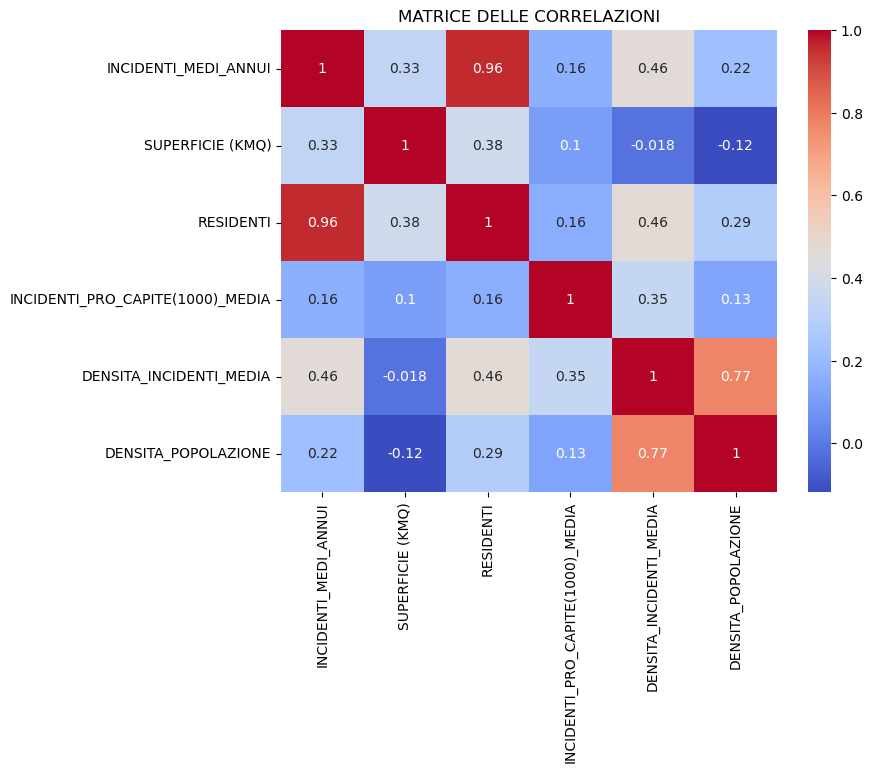

In [69]:
#Costruisco una heatmap in maniera tale da poter formulare le ipotesi che andrò a testare
plt.figure(figsize=(8, 6))
sns.heatmap(corr_accidents,annot=True,cmap="coolwarm")

plt.title("MATRICE DELLE CORRELAZIONI")
plt.show()

# ANALISI DEGLI OUTLIERS

La Classe comunale che verrà principalmente osservata per questi outlier sarà quella demografica, poichè l' incidenza degli incidenti sulla popolazione è la base della nostra analisi.

## Analisi outlier residenti
Osservo quali siano gli outlier, poichè essendoci ad esempio in residenti ed essendo questa molto correlata agli incidenti, voglio capire se siano dati falsati o abbiano un senso.

Outlier di RESIDENTI--> ci partendo da comuni con più di 13512.720 abitanti

In [70]:
outliers_lower,outliers_upper=fn.outliers(df_accidents_municipality,"RESIDENTI")
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

ANALISI OUTLIER - RESIDENTI
Q1: 1014.875
Q3: 6020.917
IQR: 5006.042
Limite inferiore: -6494.188
Limite superiore: 13529.979
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 826
Percentuale sul totale: 10.033%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5014,58091.0,Roma,390605,2.693100e+06,1287.499925,12,Lazio,24,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1830,15146.0,Milano,272545,1.310566e+06,181.702871,3,Lombardia,24,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
5399,63049.0,Napoli,60731,9.588668e+05,118.998133,15,Campania,24,2530.458333,8057.830529,21.264689,2.639009,Grande,Grande
271,1272.0,Torino,87227,8.728376e+05,130.021463,1,Piemonte,24,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
6901,82053.0,Palermo,54030,6.582088e+05,160.602017,19,Sicilia,24,2251.250000,4098.384609,14.017570,3.420267,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4502,48021.0,Greve in Chianti,817,1.366446e+04,169.374296,9,Toscana,24,34.041667,80.676104,0.200985,2.491256,Medio,Grande
6166,71060.0,Vieste,566,1.362875e+04,169.201963,16,Puglia,24,23.583333,80.547234,0.139380,1.730411,Medio,Grande
1873,15213.0,Solaro,1021,1.362700e+04,6.675996,3,Lombardia,24,42.541667,2041.193605,6.372333,3.121866,Medio,Molto piccolo
1837,15159.0,Opera,963,1.361104e+04,7.634883,3,Lombardia,24,40.125000,1782.743897,5.255483,2.947974,Medio,Molto piccolo


CLASSE_DEMOGRAFICA
Grande    506
Medio     320
Name: count, dtype: int64

## Analisi outlier superficie
Osservo quali siano gli outlier 

Outlier di SUPERFICIE--> il limite superiore è intorno ai 95 kmq, outliers esistono solo oltre quel limite e rappresentano 8.54% (736 comuni) sul totale, sono principalmente comuni grandi/ molto grandi.

In [71]:
outliers_lower, outliers_upper = fn.outliers(df_accidents_municipality,"SUPERFICIE (KMQ)")

outliers_upper["CLASSE_SUPERFICIE"].value_counts()

ANALISI OUTLIER - SUPERFICIE (KMQ)
Q1: 11.296
Q3: 43.801
IQR: 32.504
Limite inferiore: -37.460
Limite superiore: 92.557
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 695
Percentuale sul totale: 8.442%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5014,58091.0,Roma,390605,2.693100e+06,1287.499925,12,Lazio,24,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
4159,39014.0,Ravenna,21748,1.525028e+05,654.033092,8,Emilia-Romagna,24,906.166667,233.172962,1.385506,5.941966,Grande,Molto grande
6129,71020.0,Cerignola,4047,5.762283e+04,593.918008,16,Puglia,24,168.625000,97.021529,0.283920,2.926357,Grande,Molto grande
7206,89013.0,Noto,1304,2.369438e+04,555.023042,19,Sicilia,24,54.333333,42.690795,0.097894,2.293090,Grande,Molto grande
7278,90064.0,Sassari,13688,1.242437e+05,547.040592,20,Sardegna,24,570.333333,227.119648,1.042580,4.590442,Grande,Molto grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7212,89019.0,Sortino,85,8.722792e+03,93.329558,19,Sicilia,24,3.541667,93.462262,0.037948,0.406024,Medio,Medio
6071,70046.0,Montenero di Bisaccia,217,6.540958e+03,93.298117,14,Molise,24,9.041667,70.108150,0.096912,1.382315,Medio,Medio
4671,53001.0,Arcidosso,183,4.262500e+03,93.254100,9,Toscana,24,7.625000,45.708446,0.081766,1.788856,Piccolo,Medio
3590,28060.0,Padova,33893,2.077101e+05,93.011371,5,Veneto,24,1412.208333,2233.168713,15.183179,6.798940,Grande,Medio


CLASSE_SUPERFICIE
Grande          532
Medio            93
Molto grande     70
Name: count, dtype: int64

## Outliers incidenti medi annui

In [72]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"INCIDENTI_MEDI_ANNUI")

ANALISI OUTLIER - INCIDENTI_MEDI_ANNUI
Q1: 1.000
Q3: 11.333
IQR: 10.333
Limite inferiore: -14.500
Limite superiore: 26.833
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 1052
Percentuale sul totale: 12.778%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5014,58091.0,Roma,390605,2.693100e+06,1287.499925,12,Lazio,24,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1830,15146.0,Milano,272545,1.310566e+06,181.702871,3,Lombardia,24,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1291,10025.0,Genova,102694,5.862910e+05,240.190217,7,Liguria,24,4278.916667,2440.944375,17.814700,7.298282,Grande,Grande
271,1272.0,Torino,87227,8.728376e+05,130.021463,1,Piemonte,24,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
4498,48017.0,Firenze,74537,3.646007e+05,102.315325,9,Toscana,24,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3928,34018.0,Langhirano,650,9.870000e+03,70.842396,8,Emilia-Romagna,24,27.083333,139.323351,0.382304,2.744005,Medio,Medio
5902,68027.0,Penne,649,1.225529e+04,91.194071,13,Abruzzo,24,27.041667,134.386935,0.296529,2.206530,Medio,Medio
1432,12067.0,Fagnano Olona,648,1.182938e+04,8.680950,3,Lombardia,24,27.000000,1362.682080,3.110259,2.282454,Medio,Molto piccolo
5315,62043.0,Montesarchio,647,1.324400e+04,26.507300,15,Campania,24,26.958333,499.635949,1.017015,2.035513,Medio,Piccolo


In [73]:
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

CLASSE_DEMOGRAFICA
Medio      556
Grande     490
Piccolo      6
Name: count, dtype: int64

In [74]:
outliers_upper[outliers_upper["CLASSE_DEMOGRAFICA"] == "Piccolo"]

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1209,9012.0,Borghetto Santo Spirito,885,4971.916667,5.393050,7,Liguria,24,36.875000,921.911843,6.837504,7.416657,Piccolo,Molto piccolo
7673,97001.0,Abbadia Lariana,729,3206.166667,16.658875,3,Lombardia,24,30.375000,192.459975,1.823352,9.473930,Piccolo,Piccolo
3914,34004.0,Berceto,726,2160.958333,131.704583,8,Emilia-Romagna,24,30.250000,16.407617,0.229681,13.998419,Piccolo,Grande
4163,39018.0,Solarolo,711,4416.416667,26.038283,8,Emilia-Romagna,24,29.625000,169.612436,1.137748,6.707927,Piccolo,Piccolo
1254,9057.0,Spotorno,682,3753.791667,8.019750,7,Liguria,24,28.416667,468.068414,3.543336,7.570124,Piccolo,Molto piccolo
4694,53024.0,Scarlino,656,3659.125000,88.267629,9,Toscana,24,27.333333,41.454892,0.309664,7.469910,Piccolo,Medio


In [75]:
outliers_upper_region = (outliers_upper.groupby("REGIONE", as_index=False)
                         .agg(NUM_COMUNI=("COMUNE", "count"),
                              COMUNI=("COMUNE", ", ".join)))

outliers_upper_region.sort_values("NUM_COMUNI", ascending=False)

,REGIONE,NUM_COMUNI,COMUNI
8,Lombardia,180,"Milano, Brescia, Bergamo, Monza, Como, Pavia, ..."
19,Veneto,119,"Verona, Padova, Venezia, Vicenza, Treviso, Chi..."
4,Emilia-Romagna,117,"Bologna, Rimini, Modena, Reggio nell'Emilia, P..."
15,Toscana,101,"Firenze, Prato, Livorno, Pisa, Lucca, Viareggi..."
12,Puglia,80,"Bari, Taranto, Foggia, Lecce, Brindisi, Barlet..."
14,Sicilia,72,"Palermo, Catania, Messina, Siracusa, Trapani, ..."
3,Campania,66,"Napoli, Salerno, Pozzuoli, Caserta, Battipagli..."
6,Lazio,64,"Roma, Latina, Fiumicino, Viterbo, Aprilia, Rie..."
11,Piemonte,57,"Torino, Alessandria, Novara, Asti, Cuneo, Biel..."
7,Liguria,35,"Genova, La Spezia, Savona, Sanremo, Imperia, A..."


## Outliers densità incidenti media

In [76]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"DENSITA_INCIDENTI_MEDIA")
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

ANALISI OUTLIER - DENSITA_INCIDENTI_MEDIA
Q1: 0.042
Q3: 0.553
IQR: 0.511
Limite inferiore: -0.724
Limite superiore: 1.318
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 987
Percentuale sul totale: 11.988%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1830,15146.0,Milano,272545,1.310566e+06,181.702871,3,Lombardia,24,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1796,15077.0,Cinisello Balsamo,9859,7.300467e+04,12.724083,3,Lombardia,24,410.791667,5737.518747,32.284578,5.626923,Grande,Piccolo
4498,48017.0,Firenze,74537,3.646007e+05,102.315325,9,Toscana,24,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
1803,15093.0,Corsico,3901,3.376558e+04,5.358042,3,Lombardia,24,162.541667,6301.851578,30.336021,4.813827,Grande,Molto piccolo
271,1272.0,Torino,87227,8.728376e+05,130.021463,1,Piemonte,24,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,13212.0,Senna Comasco,89,3.116375e+03,2.786817,3,Lombardia,24,3.708333,1118.256194,1.330670,1.189951,Piccolo,Molto piccolo
7747,97075.0,Sirone,102,2.329625e+03,3.202083,3,Lombardia,24,4.250000,727.534157,1.327261,1.824328,Piccolo,Molto piccolo
4243,41050.0,Saltara,318,6.289750e+03,9.985300,11,Marche,16,13.250000,629.900954,1.326951,2.106602,Medio,Molto piccolo
6994,83064.0,Pace del Mela,388,6.190583e+03,12.187312,19,Sicilia,24,16.166667,507.953114,1.326516,2.611493,Medio,Piccolo


CLASSE_DEMOGRAFICA
Medio            494
Grande           340
Piccolo          145
Molto piccolo      8
Name: count, dtype: int64

In [77]:
#Outliers di classe demografica piccolo e molto piccolo raggruppato per regione con numero di comuni
(outliers_upper[outliers_upper["CLASSE_DEMOGRAFICA"].isin(["Piccolo", "Molto piccolo"])].groupby("REGIONE").agg(NUM_COMUNI=("COMUNE", "count"),
                                                                                                                COMUNI=("COMUNE", ", ".join))
                                                                                                                .sort_values(by="NUM_COMUNI",ascending=False))

,NUM_COMUNI,COMUNI
REGIONE,,
Lombardia,105,"Malgrate, Pescate, Grandate, Buguggiate, Lozza..."
Liguria,14,"Borghetto Santo Spirito, Laigueglia, Borgio Ve..."
Piemonte,9,"Gaglianico, Dormelletto, Paruzzaro, Banchette,..."
Marche,4,"Pedaso, Numana, Castelbellino, Colli del Tronto"
Campania,4,"Atrani, Lacco Ameno, Conca dei Marini, Minori"
Veneto,4,"Battaglia Terme, Pastrengo, Nove, Grisignano d..."
Trentino-Alto Adige,4,"Fiera di Primiero, Nogaredo, San Michele all'A..."
Sicilia,3,"Aci Bonaccorsi, Valdina, Venetico"
Lazio,2,"Colonna, Nazzano"


In [78]:
#Outliers di classe demografica totale raggruppato per regione con numero di comuni
outliers_upper_region = (outliers_upper.groupby("REGIONE", as_index=False)
                         .agg(NUM_COMUNI=("COMUNE", "count"),
                              COMUNI=("COMUNE", ", ".join)))

outliers_upper_region.sort_values("NUM_COMUNI", ascending=False)

,REGIONE,NUM_COMUNI,COMUNI
7,Lombardia,395,"Milano, Cinisello Balsamo, Corsico, Cormano, B..."
2,Campania,112,"Napoli, Portici, Aversa, Casavatore, San Giorg..."
18,Veneto,88,"Padova, Verona, Treviso, Vicenza, Conegliano, ..."
10,Piemonte,54,"Torino, Collegno, Beinasco, Nichelino, Gruglia..."
14,Toscana,50,"Firenze, Viareggio, Forte dei Marmi, Prato, Ca..."
6,Liguria,48,"Genova, Chiavari, Albissola Marina, Vallecrosi..."
3,Emilia-Romagna,46,"Riccione, Bologna, Cattolica, Rimini, Casalecc..."
13,Sicilia,42,"Palermo, Gravina di Catania, Villabate, Sant'A..."
5,Lazio,37,"Roma, Ciampino, Frosinone, Albano Laziale, Anz..."
8,Marche,32,"San Benedetto del Tronto, Porto San Giorgio, P..."


## Outliers incidenti pro capite media

In [79]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"DENSITA_INCIDENTI_MEDIA")


ANALISI OUTLIER - DENSITA_INCIDENTI_MEDIA
Q1: 0.042
Q3: 0.553
IQR: 0.511
Limite inferiore: -0.724
Limite superiore: 1.318
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 987
Percentuale sul totale: 11.988%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,N_ANNI,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1830,15146.0,Milano,272545,1.310566e+06,181.702871,3,Lombardia,24,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1796,15077.0,Cinisello Balsamo,9859,7.300467e+04,12.724083,3,Lombardia,24,410.791667,5737.518747,32.284578,5.626923,Grande,Piccolo
4498,48017.0,Firenze,74537,3.646007e+05,102.315325,9,Toscana,24,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
1803,15093.0,Corsico,3901,3.376558e+04,5.358042,3,Lombardia,24,162.541667,6301.851578,30.336021,4.813827,Grande,Molto piccolo
271,1272.0,Torino,87227,8.728376e+05,130.021463,1,Piemonte,24,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1651,13212.0,Senna Comasco,89,3.116375e+03,2.786817,3,Lombardia,24,3.708333,1118.256194,1.330670,1.189951,Piccolo,Molto piccolo
7747,97075.0,Sirone,102,2.329625e+03,3.202083,3,Lombardia,24,4.250000,727.534157,1.327261,1.824328,Piccolo,Molto piccolo
4243,41050.0,Saltara,318,6.289750e+03,9.985300,11,Marche,16,13.250000,629.900954,1.326951,2.106602,Medio,Molto piccolo
6994,83064.0,Pace del Mela,388,6.190583e+03,12.187312,19,Sicilia,24,16.166667,507.953114,1.326516,2.611493,Medio,Piccolo


In [80]:
df_accidents_municipality.to_csv("../Data/Df_clean/df_accidents_municipality_aggregate_years.csv",index=False)